In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com' # Set Hugging Face endpoint to a mirror
os.chdir('./Interkcat')

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from model import InterKcat, KcatDataset, collate_fn
from torch.utils.data import Dataset, DataLoader

In [3]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 1234
EPOCHS = 200

df = pd.read_csv('EITLEM_KCAT.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values

# Split  Train : Dev : Test = 80 : 10 : 10
train_seq, temp_seq, train_smiles, temp_smiles, train_kcat, temp_kcat = train_test_split(
        sequences, smiles_list, kcats,
        test_size=0.2,
        random_state=SEED
    )


dev_seq, test_seq, dev_smiles, test_smiles, dev_kcat, test_kcat = train_test_split(
    temp_seq, temp_smiles, temp_kcat,
    test_size=0.5,
    random_state=SEED
)

# Dataset
train_dataset = KcatDataset(train_seq, train_smiles, train_kcat)
dev_dataset = KcatDataset(dev_seq, dev_smiles, dev_kcat)
test_dataset = KcatDataset(test_seq, test_smiles, test_kcat)

### Model apply for mutant influence prediction

In [60]:
from tqdm import tqdm

# Load best model and evaluate on test set
model_path = './interkcat_both_lr0.0001_bs128_md256/best_interkcat_model.pth'
model = InterKcat(prot_dim=640, mol_dim=256).to(DEVICE)
model.load_state_dict(torch.load(model_path))
model.eval()

BATCH_SIZE = 256
df = pd.read_csv('EITLEM_KCAT_with_mutations_dev_test.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values
dataset = KcatDataset(sequences, smiles_list, kcats)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

all_preds = []
with torch.no_grad():
    for seq_batch, smiles_batch, kcat_batch in tqdm(data_loader):
        kcat_pred = model(
            protein_sequences=seq_batch,
            smiles_list=smiles_batch,
            inter_model="both"
        )
        all_preds.extend(kcat_pred.cpu().numpy())
    all_preds = np.array(all_preds)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
100%|███████████████████████████████████████████| 27/27 [03:16<00:00,  7.27s/it]


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset with mutations
df = pd.read_csv('EITLEM_KCAT_with_mutations_dev_test.csv')
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
wt_counts = df[df['type'] == 'wild'].groupby(group_keys).size().reset_index(name='wt_count')

# Only keep groups that have exactly one WT sample (strict baseline)
single_wt_groups = wt_counts[wt_counts['wt_count'] == 1][group_keys]
wt_data = df[df['type'] == 'wild'].merge(single_wt_groups, on=group_keys)
baseline_data = wt_data[group_keys + ['log_kcat', 'pred_log_kcat']].copy()

# Rename columns for baseline
baseline_data.rename(columns={
    'log_kcat': 'single_wt_log_kcat',
    'pred_log_kcat': 'single_pred_wt_log_kcat'
}, inplace=True)

# Filter out mutant data that belongs to these "single WT groups"
mutant_df = df[df['type'] == 'mutant'].merge(single_wt_groups, on=group_keys)

# Merge baseline data into mutant data (now mutants have a clean one-to-one baseline)
eval_df = mutant_df.merge(baseline_data, on=group_keys, how='inner')

def get_change(val, base):
    if pd.isna(val) or pd.isna(base):
        return 'Unknown'
    diff = val - base
    if diff > 1e-6:
        return 'Increase'
    elif diff < -1e-6:
        return 'Decrease'
    else:
        return 'Unchanged'

eval_df['kcat_change'] = eval_df.apply(lambda row: get_change(row['log_kcat'], row['single_wt_log_kcat']), axis=1)
eval_df['pred_kcat_change'] = eval_df.apply(lambda row: get_change(row['pred_log_kcat'], row['single_pred_wt_log_kcat']), axis=1)

def count_mutation_sites(val):
    if pd.isna(val) or val == 'No WT available' or val == 'WT':
        return pd.NA
    return str(val).count(';') + 1

eval_df['mutation_sites_count'] = eval_df['Mutation_Info'].apply(count_mutation_sites)
eval_df = eval_df[eval_df['kcat_change'].isin(['Increase', 'Decrease'])].copy()
eval_df['is_correct'] = (eval_df['kcat_change'] == eval_df['pred_kcat_change']).astype(int)

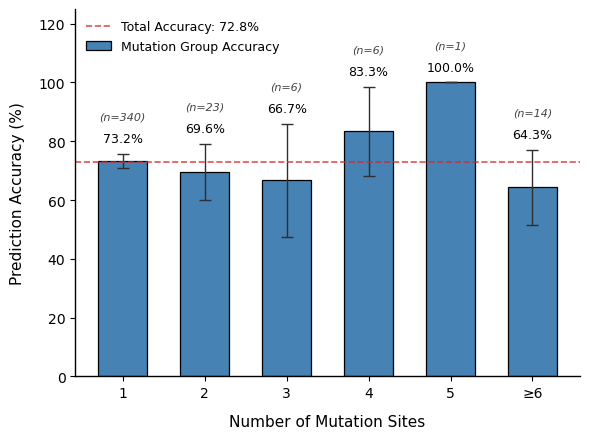

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('single_wt_evaluation_results.csv')

def group_mutations(n):
    if pd.isna(n): return 'Unknown'
    return '≥6' if n >= 6 else str(int(n))

df['mut_group'] = df['mutation_sites_count'].apply(group_mutations)
group_order = ['1', '2', '3', '4', '5', '≥6']

acc_grouped = df.groupby('mut_group')['is_correct'].agg(
    total='count', 
    correct='sum'
).reindex(group_order).reset_index()

acc_grouped['accuracy'] = (acc_grouped['correct'] / acc_grouped['total']) * 100
p = acc_grouped['correct'] / acc_grouped['total']
acc_grouped['se'] = np.sqrt(p * (1 - p) / acc_grouped['total']) * 100
overall_acc = (df['is_correct'].sum() / len(df)) * 100

plt.rcParams.update({
    'font.size': 10, 
    'font.family': 'sans-serif', 
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans'],
    'axes.linewidth': 1.0
})

fig, ax = plt.subplots(figsize=(6, 4.5))
bar_color = '#4682B4' 

bars = ax.bar(
    acc_grouped['mut_group'], acc_grouped['accuracy'], 
    yerr=acc_grouped['se'],
    color=bar_color, edgecolor='black', linewidth=0.9, width=0.6, 
    capsize=4, error_kw={'elinewidth': 1.0, 'ecolor': '#2F2F2F'},
    label='Mutation Group Accuracy'
)

ax.set_ylim(0, 125)
ax.set_xlabel('Number of Mutation Sites', fontsize=11, labelpad=10)
ax.set_ylabel('Prediction Accuracy (%)', fontsize=11, labelpad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.axhline(overall_acc, color='#D62728', linestyle='--', linewidth=1.2, alpha=0.8, 
           label=f'Total Accuracy: {overall_acc:.1f}%')

for i, bar in enumerate(bars):
    acc_val = acc_grouped.iloc[i]['accuracy']
    n_val = acc_grouped.iloc[i]['total']
    se_val = acc_grouped.iloc[i]['se']
    
    if pd.isna(acc_val): continue
    base_y = max(acc_val + se_val, acc_val)
    
    ax.text(bar.get_x() + bar.get_width()/2, base_y + 3, f'{acc_val:.1f}%', 
            ha='center', va='bottom', fontsize=9, color='black')
    
    ax.text(bar.get_x() + bar.get_width()/2, base_y + 11, f'(n={int(n_val)})', 
            ha='center', va='bottom', fontsize=8, color='#444444', fontstyle='italic')

ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig("./Figure/Mutation_Site_Accuracy.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Ablation Study: p2m_atten only m2p_atten only

In [41]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tqdm import tqdm

def evaluate_ablation(model, data_loader, mode="both", device="cuda"):
    model.eval()
    all_preds = []
    all_targets = []

    dummy_real_seq = data_loader.dataset[0][0]
    dummy_real_smiles = data_loader.dataset[0][1]

    with torch.no_grad():
        for seq_batch, smiles_batch, kcat_batch in tqdm(data_loader):
            
            if mode == "seq_only":
                ablated_smiles_batch = [dummy_real_smiles] * len(smiles_batch)
                ablated_seq_batch = seq_batch
            
            elif mode == "smiles_only":
                ablated_seq_batch = [dummy_real_seq] * len(seq_batch)
                ablated_smiles_batch = smiles_batch
            
            else: # "both"
                ablated_seq_batch = seq_batch
                ablated_smiles_batch = smiles_batch

            kcat_pred = model(
                protein_sequences=ablated_seq_batch,
                smiles_list=ablated_smiles_batch,
                inter_model="both"
            )

            all_preds.extend(kcat_pred.cpu().numpy())
            all_targets.extend(kcat_batch.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)

    return {"Prediction": all_preds, "Target": all_targets, "RMSE": rmse, "R2": r2, "MAE": mae}

In [48]:
# Hyperparameters
SEED = 1234 # Same with others
BATCH_SIZE = 256
mode = "both" # "seq_only", "smiles_only", "both"
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
metrics = evaluate_ablation(model, test_loader, mode=mode, device=DEVICE)

100%|███████████████████████████████████████████| 14/14 [01:36<00:00,  6.90s/it]


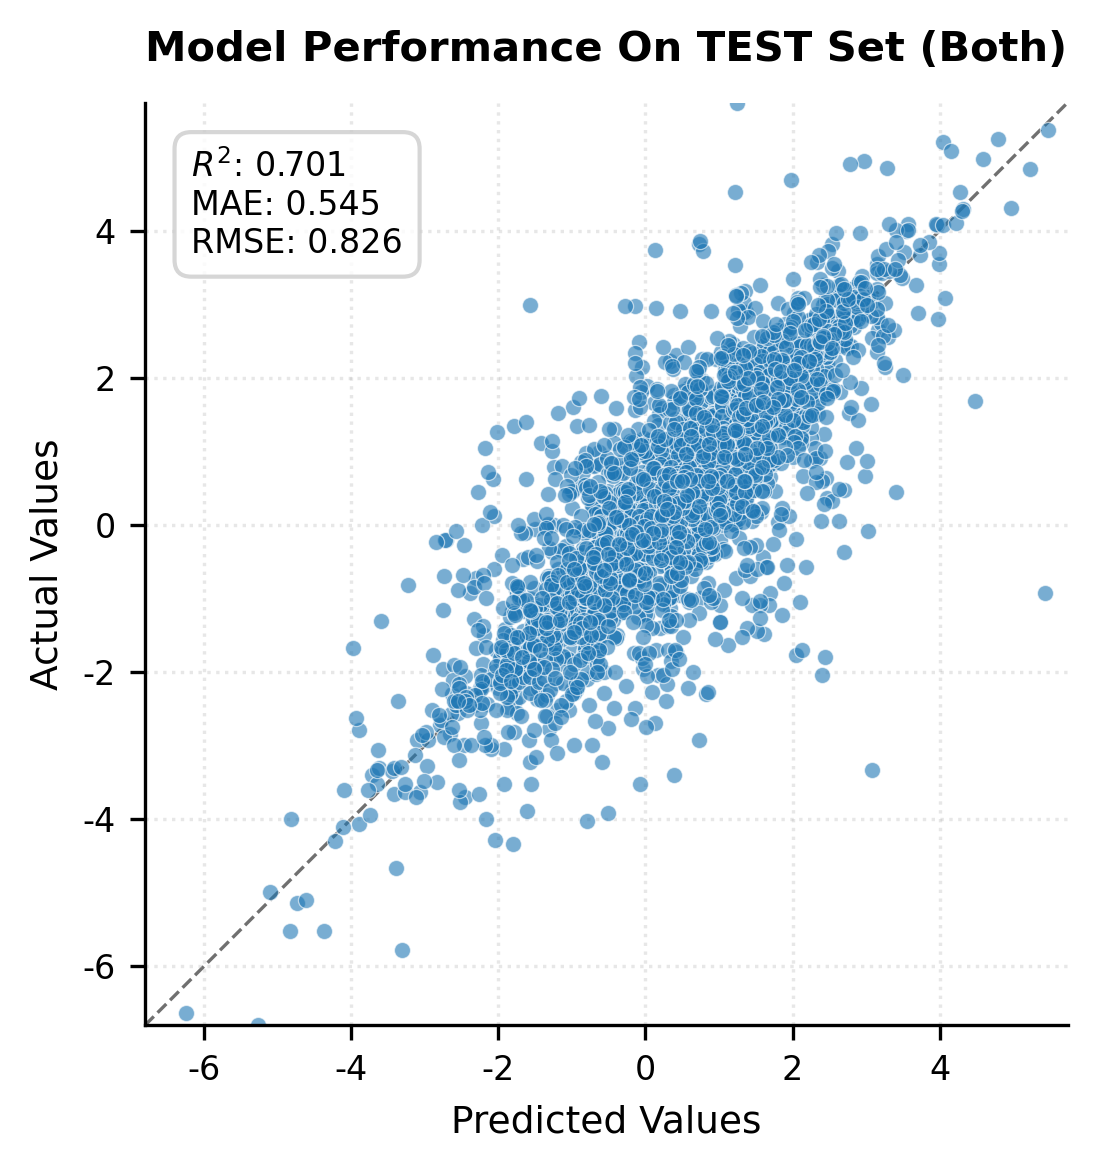

In [50]:
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# load metrics from evaluation
all_val_preds = metrics['Prediction']
all_val_targets = metrics['Target']
r2 = metrics['R2']
mae = metrics['MAE']
rmse = metrics['RMSE']

# Style settings
font_list = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_list:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_list:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# Plotting
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(all_val_preds, all_val_targets, 
           s=15,
           c='#1f77b4',
           alpha=0.6, 
           edgecolors='white',
           linewidths=0.3,
           zorder=2)

lims = [
    np.min([all_val_preds.min(), all_val_targets.min()]),
    np.max([all_val_preds.max(), all_val_targets.max()]),
]

ax.plot(lims, lims, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7, zorder=1)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Model Performance On TEST Set (Both)', fontsize=10, fontweight='bold', pad=10)
ax.set_xlabel('Predicted Values', fontsize=9)
ax.set_ylabel('Actual Values', fontsize=9)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

metrics_text = f"$R^2$: {r2:.3f}\nMAE: {mae:.3f}\nRMSE: {rmse:.3f}"
ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=8,
        verticalalignment='top', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#cccccc'), 
        zorder=3)

ax.grid(True, linestyle=':', alpha=0.3, zorder=0)

plt.tight_layout()
plt.savefig("./Figure/model_performance_both.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
file_path = "hyperparameters.xlsx"
df = pd.read_excel(file_path, header=2)

# Extract and clean TEST_R2 metrics for both groups
df_clean = df[['TEST_R2', 'TEST_R2.1']].dropna()
df_clean['TEST_R2'] = pd.to_numeric(df_clean['TEST_R2'], errors='coerce')
df_clean['TEST_R2.1'] = pd.to_numeric(df_clean['TEST_R2.1'], errors='coerce')
df_clean = df_clean.dropna()

/tmp/ipykernel_334753/3928744766.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax1,


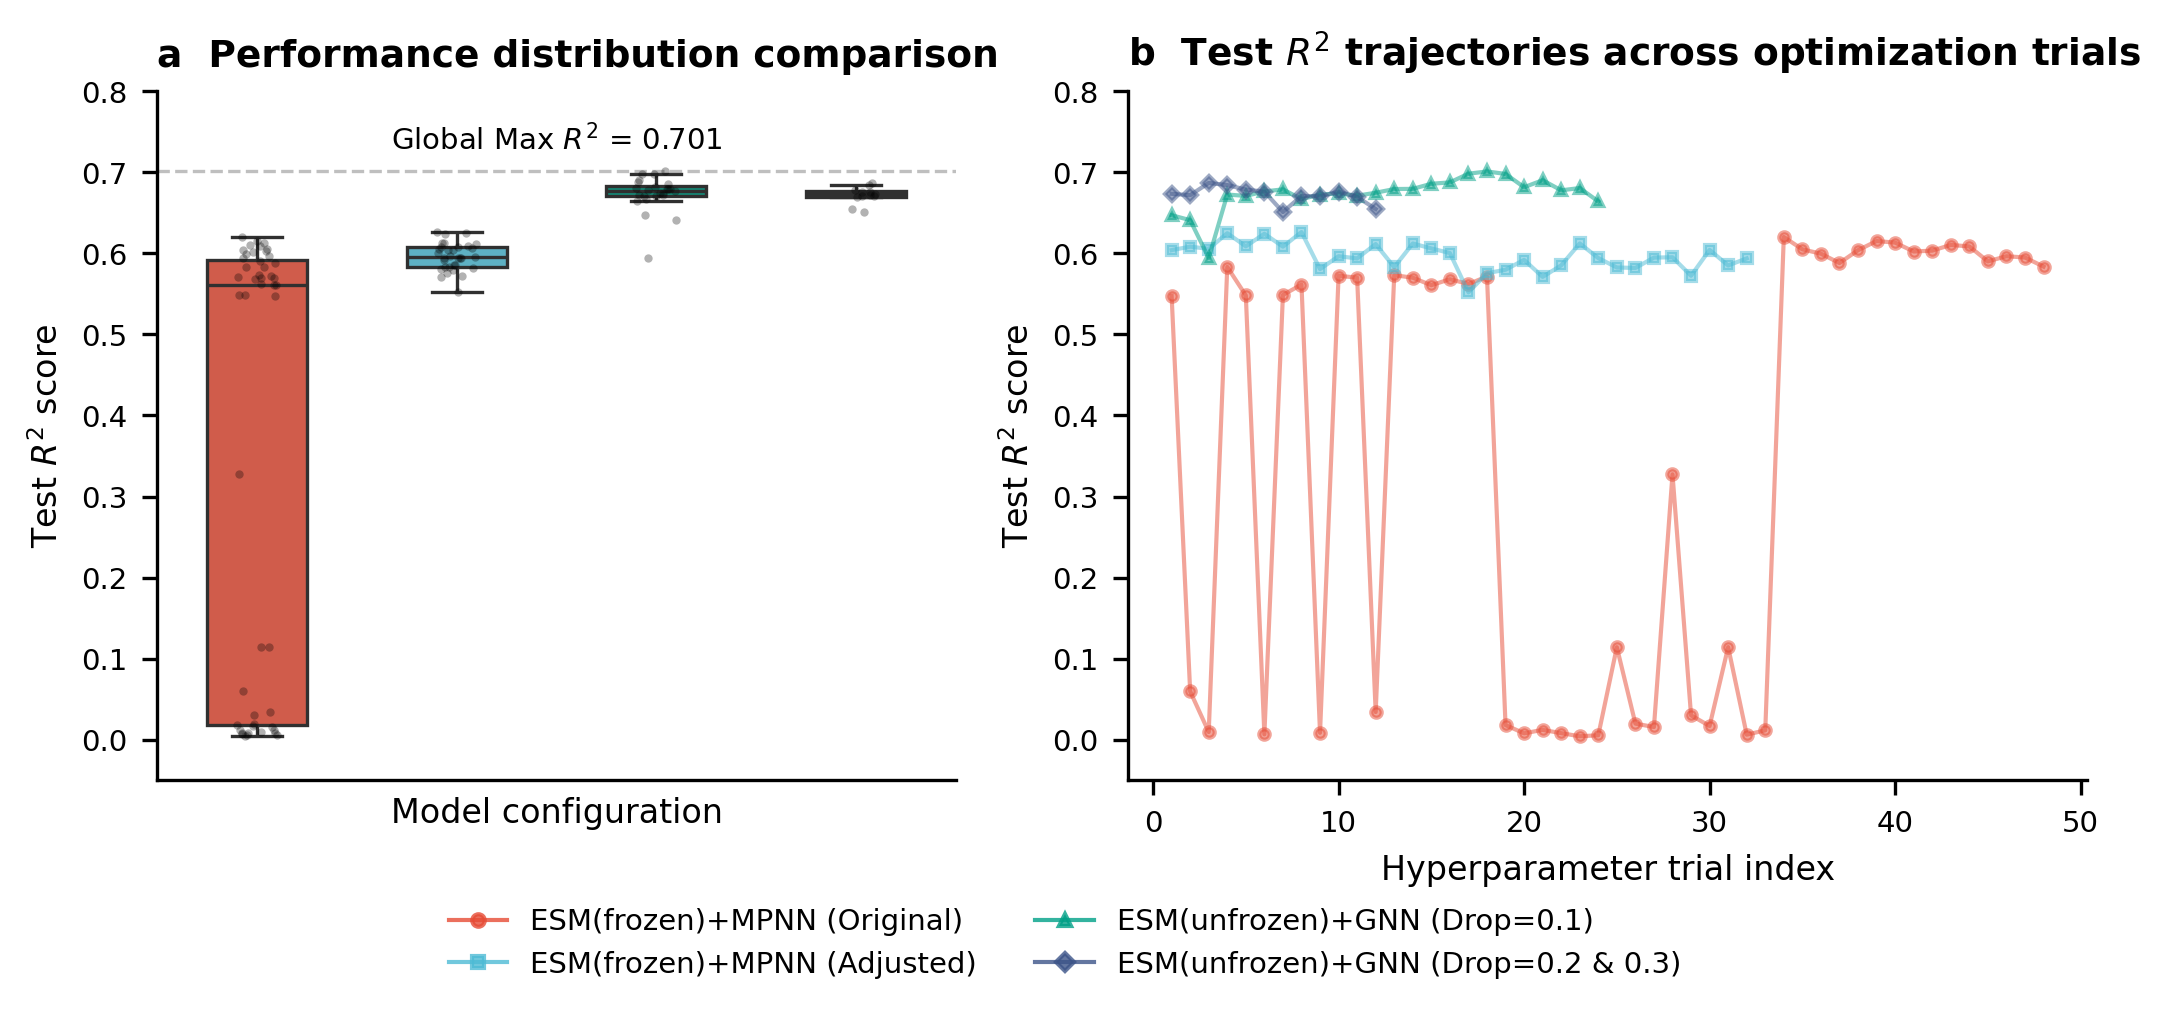

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# 1. Load Data
# Assuming the file requires skipping the first 2 rows for the main columns
file_path = "hyperparameters.xlsx"
df = pd.read_excel(file_path, header=2)

# Extract and clean TEST_R2 metrics
group1 = pd.to_numeric(df['TEST_R2'].dropna(), errors='coerce').dropna()
group2 = pd.to_numeric(df['TEST_R2.1'].dropna(), errors='coerce').dropna()
group3 = pd.to_numeric(df[df['Dropout_rate'] == 0.1]['TEST_R2.2'].dropna(), errors='coerce').dropna()
group4 = pd.to_numeric(df[df['Dropout_rate.1'].isin([0.2, 0.3])]['TEST_R2.3'].dropna(), errors='coerce').dropna()

# Structure data into a long-format DataFrame for Seaborn
data = []
for val in group1: data.append({'Group': 'ESM(frozen)+MPNN (Original)', 'Test_R2': val})
for val in group2: data.append({'Group': 'ESM(frozen)+MPNN (Adjusted)', 'Test_R2': val})
for val in group3: data.append({'Group': 'ESM(unfrozen)+GNN Drop=0.1', 'Test_R2': val})
for val in group4: data.append({'Group': 'ESM(unfrozen)+GNN Drop=0.2 & 0.3', 'Test_R2': val})
df_melted = pd.DataFrame(data)

# 2. Configure Nature-style aesthetics
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.0,
    'lines.markersize': 4,
    'figure.dpi': 300,
})

# Create 1x2 subplots with swapped width ratios (1 for Boxplot, 1.2 for Line plot)
# Increased the height slightly to 3.4 to comfortably accommodate the centralized legend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.2, 3.4), gridspec_kw={'width_ratios': [1, 1.2]})

colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488']

# --- Subplot a (Left): Boxplot + Stripplot ---
sns.boxplot(x='Group', y='Test_R2', data=df_melted, ax=ax1, 
            palette=colors, width=0.5, fliersize=0, linewidth=0.8)
sns.stripplot(x='Group', y='Test_R2', data=df_melted, ax=ax1,
              color='black', alpha=0.3, size=2, jitter=True)

ax1.set_xlabel('Model configuration')
ax1.set_ylabel('Test $R^2$ score')
ax1.set_title('a  Performance distribution comparison', loc='left', fontweight='bold')
ax1.set_ylim(-0.05, 0.8)

# Clean up axes
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks([]) # Hide X labels, rely purely on the global legend

# Annotate global maximum performance
max_r2 = df_melted['Test_R2'].max()
ax1.axhline(y=max_r2, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.text(x=1.5, y=max_r2 + 0.02, s=f'Global Max $R^2$ = {max_r2:.3f}', va='bottom', ha='center', 
         fontsize=7, color='black', transform=ax1.transData)

# --- Subplot b (Right): Fluctuation across trials ---
ax2.plot(range(1, len(group1)+1), group1, marker='o', markersize=2.5, linestyle='-', color=colors[0], alpha=0.5)
ax2.plot(range(1, len(group2)+1), group2, marker='s', markersize=2.5, linestyle='-', color=colors[1], alpha=0.5)
ax2.plot(range(1, len(group3)+1), group3, marker='^', markersize=2.5, linestyle='-', color=colors[2], alpha=0.5)
ax2.plot(range(1, len(group4)+1), group4, marker='D', markersize=2.5, linestyle='-', color=colors[3], alpha=0.5)

ax2.set_xlabel('Hyperparameter trial index')
ax2.set_ylabel('Test $R^2$ score')
ax2.set_title('b  Test $R^2$ trajectories across optimization trials', loc='left', fontweight='bold')
ax2.set_ylim(-0.05, 0.8)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 3. Global Centered Legend
# Define proxy artists to combine marker (for Subplot b) and color (for Subplot a)
legend_elements = [
    mlines.Line2D([], [], color=colors[0], marker='o', linestyle='-', markersize=3, alpha=0.8, label='ESM(frozen)+MPNN (Original)'),
    mlines.Line2D([], [], color=colors[1], marker='s', linestyle='-', markersize=3, alpha=0.8, label='ESM(frozen)+MPNN (Adjusted)'),
    mlines.Line2D([], [], color=colors[2], marker='^', linestyle='-', markersize=3, alpha=0.8, label='ESM(unfrozen)+GNN (Drop=0.1)'),
    mlines.Line2D([], [], color=colors[3], marker='D', linestyle='-', markersize=3, alpha=0.8, label='ESM(unfrozen)+GNN (Drop=0.2 & 0.3)')
]


plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.legend(handles=legend_elements, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.savefig('./Figure/model_comparison_global_legend.png', dpi=600, bbox_inches='tight', transparent=True)
plt.show()